In [1]:
# Importing all the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


In [2]:
# Loading the housing.csv file into Python
df = pd.read_csv('housing.csv')

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (20640, 10)


In [3]:
# Looking at the first 5 rows of the dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [4]:
# Getting basic info about every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


In [5]:
# Checking exactly how many values are missing in each column
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# Getting statistics for every numerical column
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
# Seeing all unique categories in ocean_proximity
print(df['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [8]:
# Looking at the column we want to predict
print("Average House Price:", df['median_house_value'].mean())
print("Cheapest House:", df['median_house_value'].min())
print("Most Expensive House:", df['median_house_value'].max())

Average House Price: 206855.81690891474
Cheapest House: 14999
Most Expensive House: 500001


In [10]:
# Filling the 207 missing values in total_bedrooms with the median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Confirming no missing values remain
print("Missing values after fixing:")
print(df.isnull().sum())

Missing values after fixing:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [11]:
# Checking how many duplicate rows exist
print("Duplicate rows before removing:", df.duplicated().sum())

# Removing duplicates
df = df.drop_duplicates()

# Confirming
print("Duplicate rows after removing:", df.duplicated().sum())
print("New shape of dataset:", df.shape)

Duplicate rows before removing: 0
Duplicate rows after removing: 0
New shape of dataset: (20640, 10)


In [12]:
# Removing capped values - houses recorded as exactly 500001
df = df[df['median_house_value'] < 500001]

print("Dataset shape after removing capped values:", df.shape)
print("Maximum house value now:", df['median_house_value'].max())

Dataset shape after removing capped values: (19675, 10)
Maximum house value now: 500000


In [13]:
# Creating 3 new meaningful columns from existing ones
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("New columns added successfully!")
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

New columns added successfully!
   rooms_per_household  bedrooms_per_room  population_per_household
0             6.984127           0.146591                  2.555556
1             6.238137           0.155797                  2.109842
2             8.288136           0.129516                  2.802260
3             5.817352           0.184458                  2.547945
4             6.281853           0.172096                  2.181467


In [14]:
# Converting ocean_proximity text column into numbers
df = pd.get_dummies(df, columns=['ocean_proximity'])

print("Encoding done! New columns created:")
print([col for col in df.columns if 'ocean' in col])
print("New shape of dataset:", df.shape)

Encoding done! New columns created:
['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
New shape of dataset: (19675, 17)


In [15]:
# Seeing which columns affect house price the most
correlation = df.corr()['median_house_value'].sort_values(ascending=False)
print("Correlation with House Price:")
print(correlation)

Correlation with House Price:
median_house_value            1.000000
median_income                 0.642611
ocean_proximity_<1H OCEAN     0.284524
ocean_proximity_NEAR BAY      0.157077
total_rooms                   0.143139
ocean_proximity_NEAR OCEAN    0.135889
rooms_per_household           0.109673
households                    0.094894
total_bedrooms                0.074178
housing_median_age            0.067948
ocean_proximity_ISLAND        0.030670
population                    0.011964
population_per_household     -0.021465
longitude                    -0.046658
latitude                     -0.148289
bedrooms_per_room            -0.196226
ocean_proximity_INLAND       -0.499008
Name: median_house_value, dtype: float64


In [16]:
# X = all input columns (features)
# y = the column we want to predict (target)

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (19675, 16)
Target shape (y): (19675,)


In [17]:
from sklearn.preprocessing import StandardScaler

# Creating the scaler
scaler = StandardScaler()

# Applying scaling to all feature columns
X_scaled = scaler.fit_transform(X)

print("Scaling done successfully!")
print("First row before scaling:", X.iloc[0].values[:3])
print("First row after scaling:", X_scaled[0][:3])

Scaling done successfully!
First row before scaling: [np.float64(-122.23) np.float64(37.88) np.int64(41)]
First row after scaling: [-1.32937755  1.03650334  1.00838834]


In [18]:
# Final confirmation that everything is ready
print("=== PREPROCESSING COMPLETE ===")
print("Total rows:", X_scaled.shape[0])
print("Total features:", X_scaled.shape[1])
print("Any missing values left:", pd.DataFrame(X_scaled).isnull().sum().sum())
print("Data is clean and ready for Machine Learning!")

=== PREPROCESSING COMPLETE ===
Total rows: 19675
Total features: 16
Any missing values left: 0
Data is clean and ready for Machine Learning!


In [19]:
import pickle

# Saving the cleaned dataframe
df.to_csv('housing_cleaned.csv', index=False)

# Saving X_scaled, X and y
import numpy as np
np.save('X_scaled.npy', X_scaled)
df.drop('median_house_value', axis=1).to_csv('X.csv', index=False)
df['median_house_value'].to_csv('y.csv', index=False)

# Saving the scaler so we can use it later for web app too
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Everything saved successfully!")
print("Files saved:")
print("   housing_cleaned.csv  - cleaned dataset")
print("   X_scaled.npy         - scaled features")
print("   X.csv                - features")
print("   y.csv                - target values")
print("   scaler.pkl           - scaler for web app later")

Everything saved successfully!
Files saved:
   housing_cleaned.csv  - cleaned dataset
   X_scaled.npy         - scaled features
   X.csv                - features
   y.csv                - target values
   scaler.pkl           - scaler for web app later


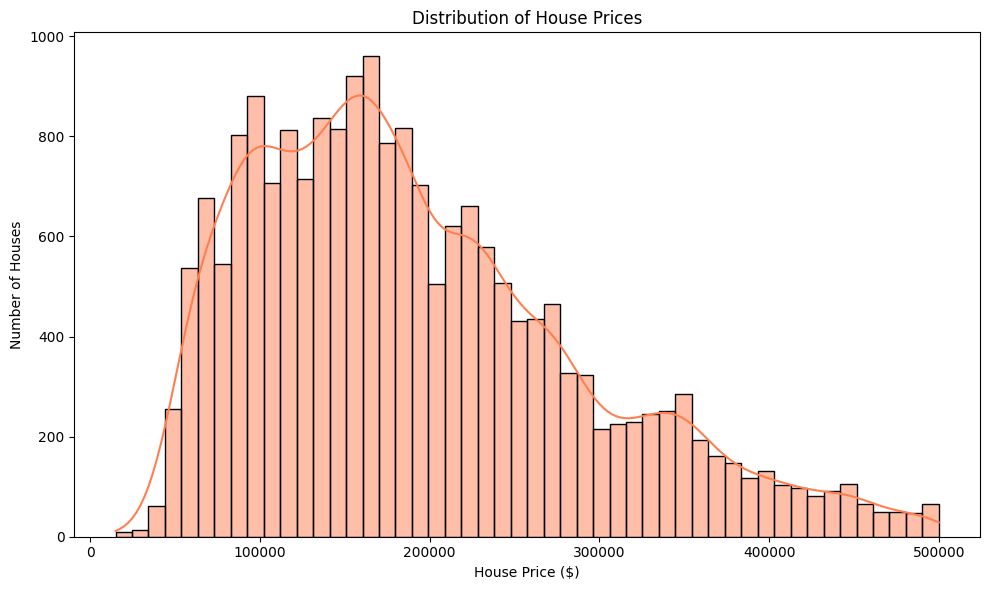

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='coral')
plt.title('Distribution of House Prices')
plt.xlabel('House Price ($)')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.show()

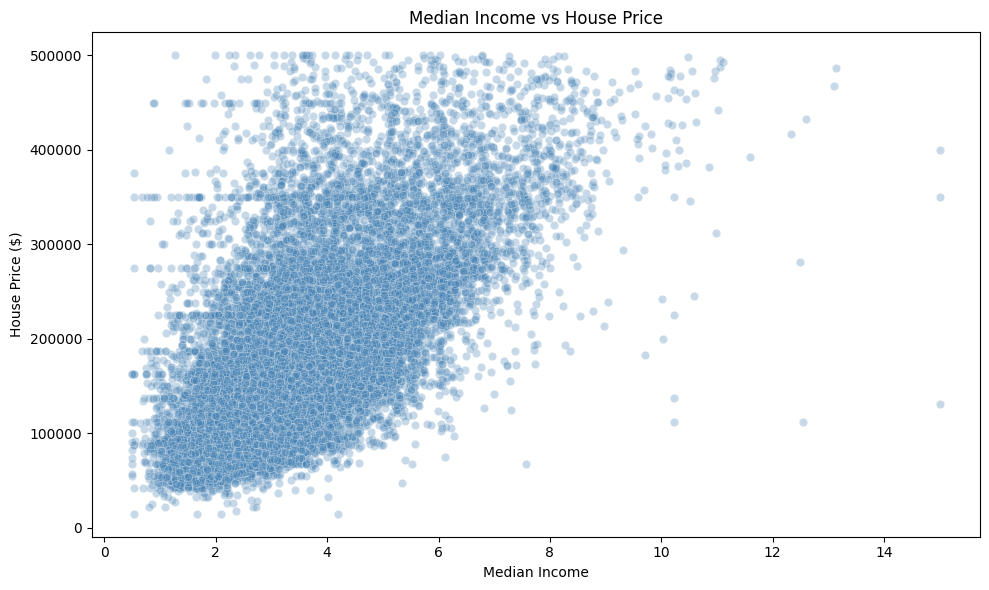

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['median_income'], y=df['median_house_value'], alpha=0.3, color='steelblue')
plt.title('Median Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('House Price ($)')
plt.tight_layout()
plt.show()

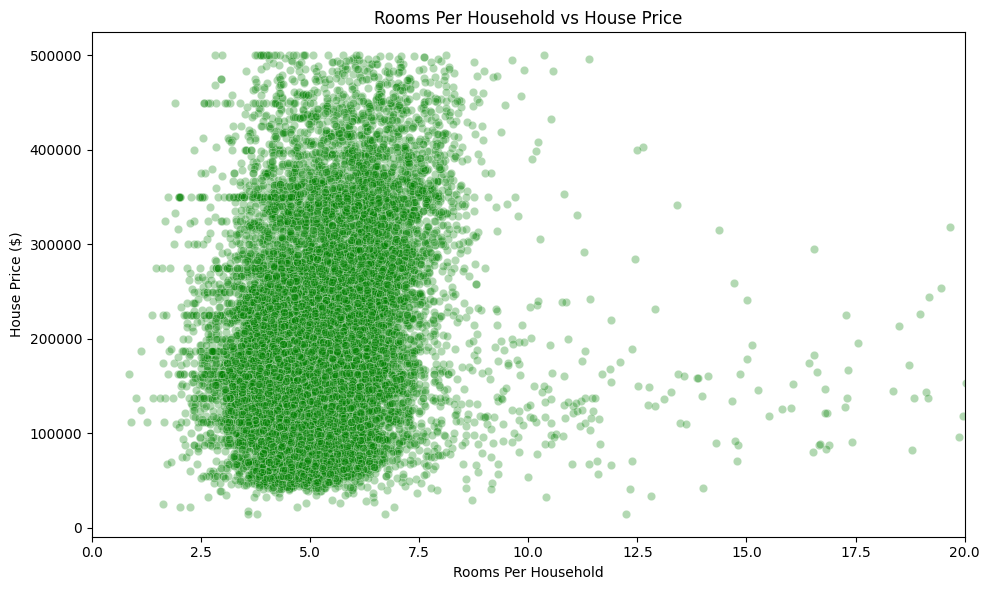

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['rooms_per_household'], y=df['median_house_value'], alpha=0.3, color='green')
plt.title('Rooms Per Household vs House Price')
plt.xlabel('Rooms Per Household')
plt.ylabel('House Price ($)')
plt.xlim(0, 20)
plt.tight_layout()
plt.show()

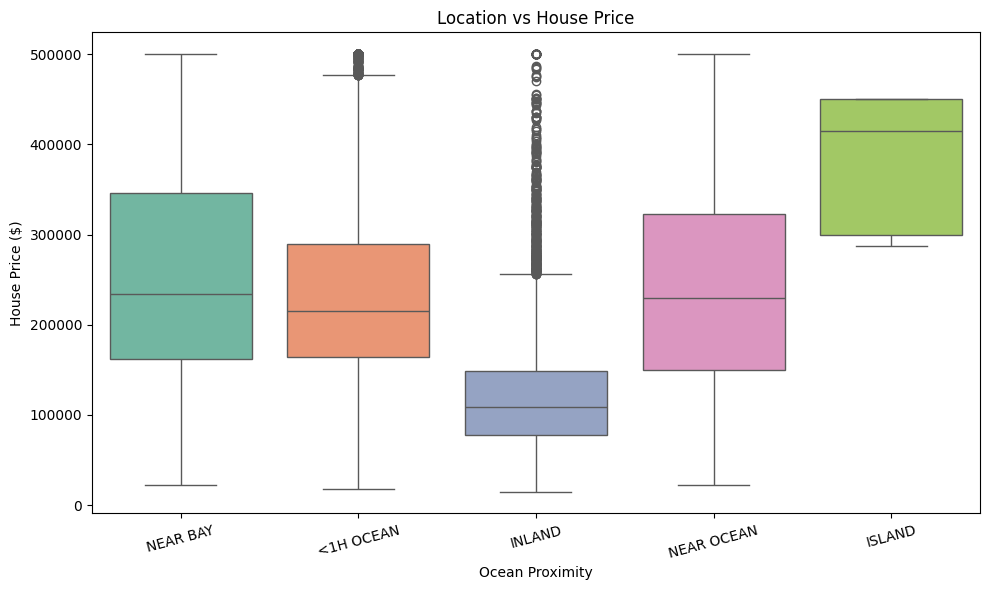

In [24]:
# Loading original dataset just for this graph
df_original = pd.read_csv('housing.csv')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_original, x='ocean_proximity', y='median_house_value', 
            hue='ocean_proximity', palette='Set2', legend=False)
plt.title('Location vs House Price')
plt.xlabel('Ocean Proximity')
plt.ylabel('House Price ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

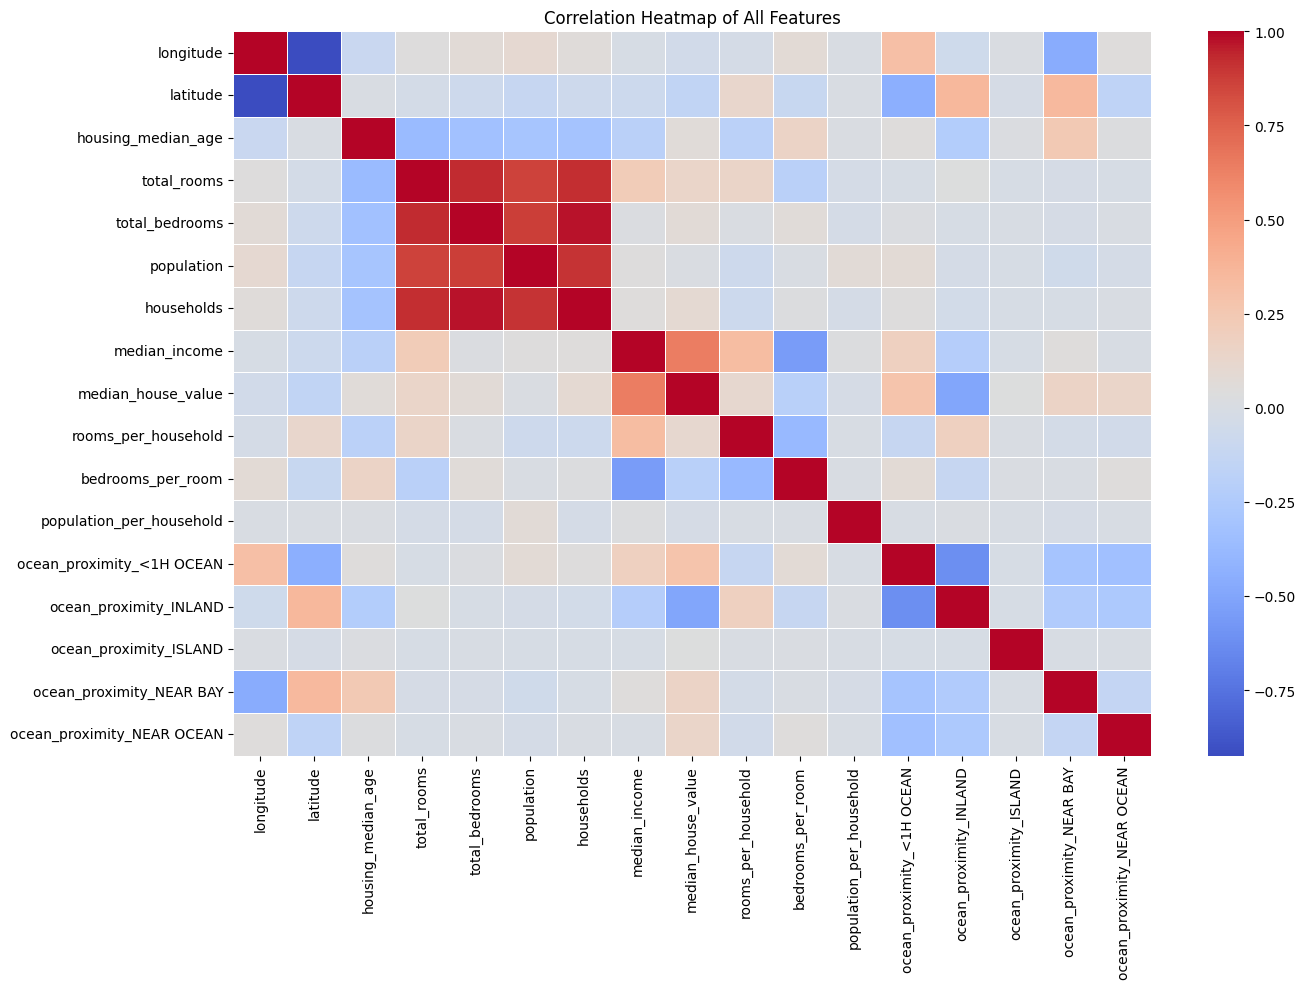

In [25]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), 
            annot=False, 
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

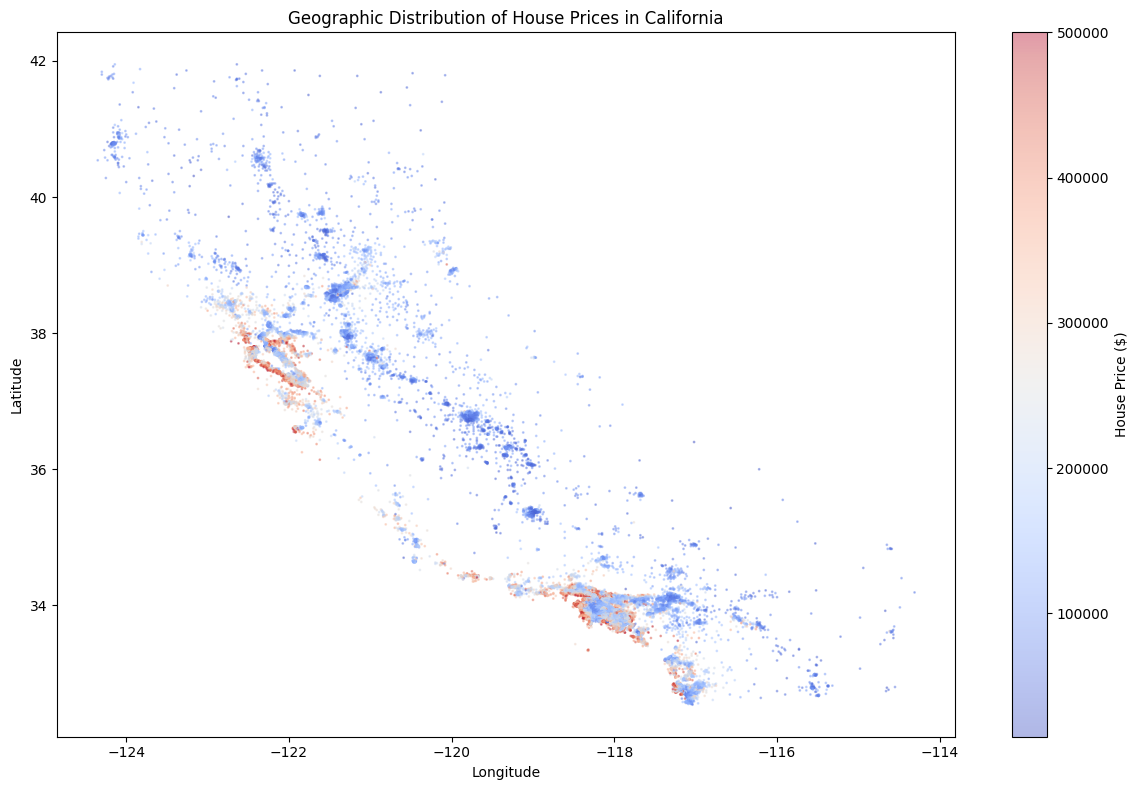

In [26]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['median_house_value'], 
                      cmap='coolwarm',
                      alpha=0.4,
                      s=1)
plt.colorbar(scatter, label='House Price ($)')
plt.title('Geographic Distribution of House Prices in California')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

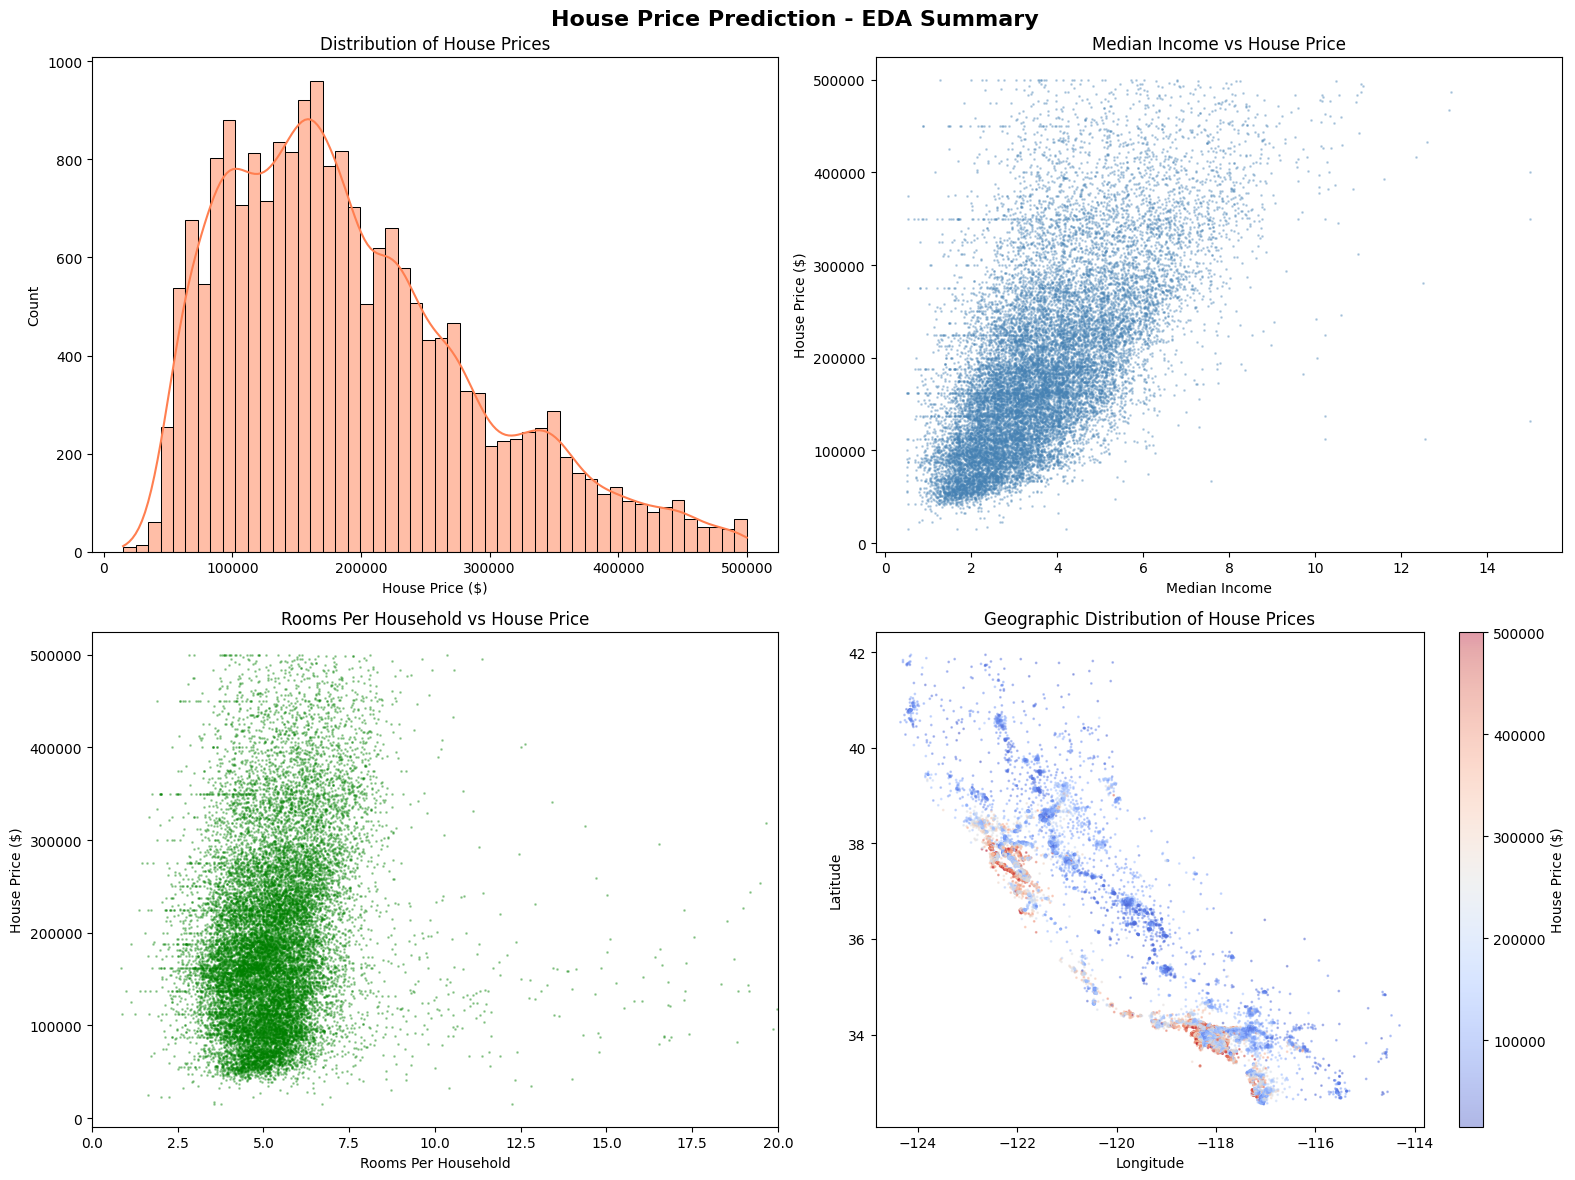

EDA Summary graph saved as eda_summary.png!


In [27]:
# Saving all graphs in one go professionally
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graph 1 - Price Distribution
sns.histplot(df['median_house_value'], bins=50, kde=True, color='coral', ax=axes[0,0])
axes[0,0].set_title('Distribution of House Prices')
axes[0,0].set_xlabel('House Price ($)')
axes[0,0].set_ylabel('Count')

# Graph 2 - Income vs Price
axes[0,1].scatter(df['median_income'], df['median_house_value'], alpha=0.3, color='steelblue', s=1)
axes[0,1].set_title('Median Income vs House Price')
axes[0,1].set_xlabel('Median Income')
axes[0,1].set_ylabel('House Price ($)')

# Graph 3 - Rooms vs Price
axes[1,0].scatter(df['rooms_per_household'], df['median_house_value'], alpha=0.3, color='green', s=1)
axes[1,0].set_title('Rooms Per Household vs House Price')
axes[1,0].set_xlabel('Rooms Per Household')
axes[1,0].set_ylabel('House Price ($)')
axes[1,0].set_xlim(0, 20)

# Graph 4 - Geographic Map
scatter = axes[1,1].scatter(df['longitude'], df['latitude'],
                             c=df['median_house_value'],
                             cmap='coolwarm',
                             alpha=0.4,
                             s=1)
fig.colorbar(scatter, ax=axes[1,1], label='House Price ($)')
axes[1,1].set_title('Geographic Distribution of House Prices')
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')

plt.suptitle('House Price Prediction - EDA Summary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA Summary graph saved as eda_summary.png!")

In [28]:
# Saving updated cleaned data with all new columns
df.to_csv('housing_cleaned.csv', index=False)
print("Progress saved successfully!")

Progress saved successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler

# Load everything back
df = pd.read_csv('housing_cleaned.csv')
X = pd.read_csv('X.csv')
y = pd.read_csv('y.csv').squeeze()
X_scaled = np.load('X_scaled.npy')
scaler = pickle.load(open('scaler.pkl', 'rb'))

print("Everything loaded successfully!")
print("df shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_scaled shape:", X_scaled.shape)

Everything loaded successfully!
df shape: (19675, 17)
X shape: (19675, 16)
y shape: (19675,)
X_scaled shape: (19675, 16)


In [2]:
from sklearn.model_selection import train_test_split

# Splitting data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data split successfully!")
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Data split successfully!
Training rows: 15740
Testing rows: 3935


In [3]:
from sklearn.linear_model import LinearRegression

# Creating and training the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Testing the model
lr_predictions = lr_model.predict(X_test)

print("Linear Regression trained successfully!")
print("Sample actual prices:", list(y_test[:5].astype(int)))
print("Sample predicted prices:", [int(x) for x in lr_predictions[:5]])

Linear Regression trained successfully!
Sample actual prices: [104200, 171200, 97300, 102700, 116500]
Sample predicted prices: [155518, 212790, 176171, 173880, 118322]


In [7]:
from sklearn.tree import DecisionTreeRegressor

# Creating and training the model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Testing the model
dt_predictions = dt_model.predict(X_test)

print("Decision Tree trained successfully!")
print("Sample actual prices:", list(y_test[:5].astype(int)))
print("Sample predicted prices:", [int(x) for x in dt_predictions[:5]])

Decision Tree trained successfully!
Sample actual prices: [104200, 171200, 97300, 102700, 116500]
Sample predicted prices: [129500, 168300, 116600, 159800, 118800]


In [10]:
from sklearn.ensemble import RandomForestRegressor

# Creating and training the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Testing the model
rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("Sample actual prices:", list(y_test[:5].astype(int)))
print("Sample predicted prices:", [int(x) for x in rf_predictions[:5]])

Random Forest trained successfully!
Sample actual prices: [104200, 171200, 97300, 102700, 116500]
Sample predicted prices: [123663, 173197, 154074, 112000, 102745]


In [11]:
from sklearn.ensemble import GradientBoostingRegressor

# Creating and training the model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Testing the model
gb_predictions = gb_model.predict(X_test)

print("Gradient Boosting trained successfully!")
print("Sample actual prices:", list(y_test[:5].astype(int)))
print("Sample predicted prices:", [int(x) for x in gb_predictions[:5]])

Gradient Boosting trained successfully!
Sample actual prices: [104200, 171200, 97300, 102700, 116500]
Sample predicted prices: [151825, 166790, 170885, 125000, 125170]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculating metrics for all 4 models
models = {
    'Linear Regression': lr_predictions,
    'Decision Tree': dt_predictions,
    'Random Forest': rf_predictions,
    'Gradient Boosting': gb_predictions
}

print("=" * 65)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>12} {'R2 Score':>10}")
print("=" * 65)

for model_name, predictions in models.items():
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    print(f"{model_name:<25} ${mae:>7,.0f} ${rmse:>11,.0f} {r2:>10.4f}")

print("=" * 65)

Model                          MAE         RMSE   R2 Score
Linear Regression         $ 45,480 $     62,205     0.6119
Decision Tree             $ 42,108 $     63,862     0.5910
Random Forest             $ 30,802 $     46,297     0.7850
Gradient Boosting         $ 35,323 $     49,973     0.7495


C:\Users\Admin\AppData\Local\Temp\ipykernel_4956\211727486.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models_names, rotation=15, ha='right')
C:\Users\Admin\AppData\Local\Temp\ipykernel_4956\211727486.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models_names, rotation=15, ha='right')


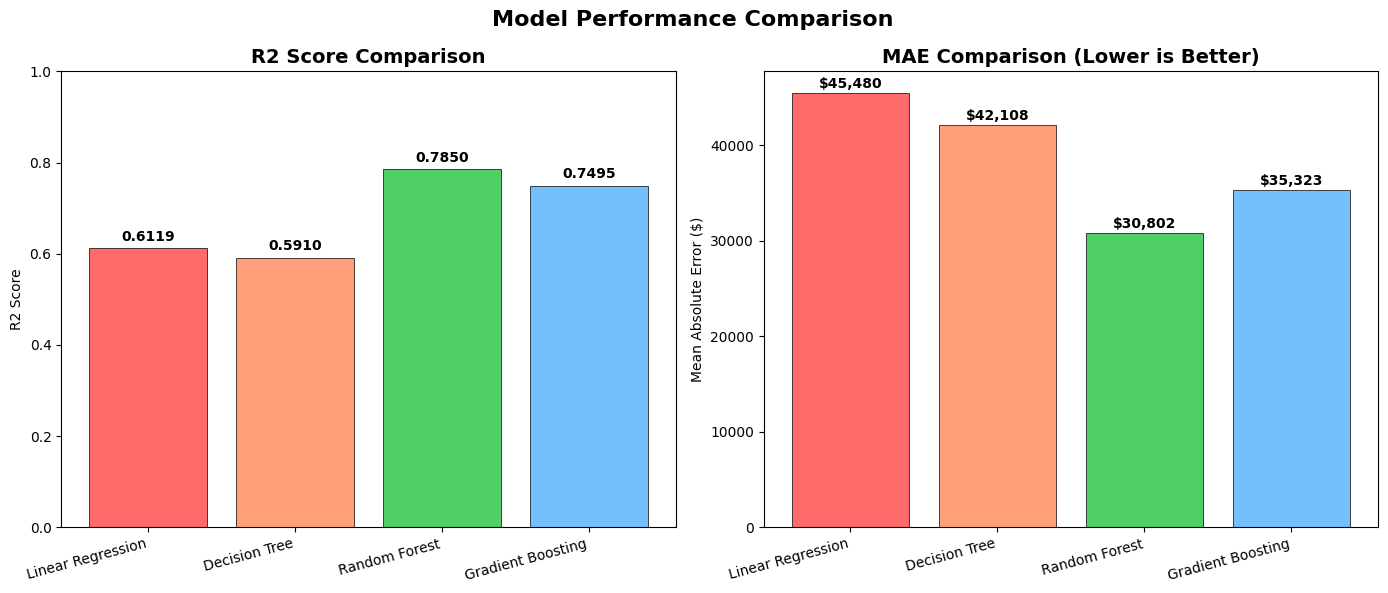

Model comparison chart saved!


In [13]:
# Creating a professional comparison bar chart
models_names = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
r2_scores = [0.6119, 0.5910, 0.7850, 0.7495]
mae_scores = [45480, 42108, 30802, 35323]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R2 Score comparison
colors = ['#ff6b6b', '#ffa07a', '#51cf66', '#74c0fc']
bars1 = axes[0].bar(models_names, r2_scores, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('R2 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(models_names, rotation=15, ha='right')
for bar, score in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# MAE comparison
bars2 = axes[1].bar(models_names, mae_scores, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].set_xticklabels(models_names, rotation=15, ha='right')
for bar, score in zip(bars2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'${score:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Model comparison chart saved!")

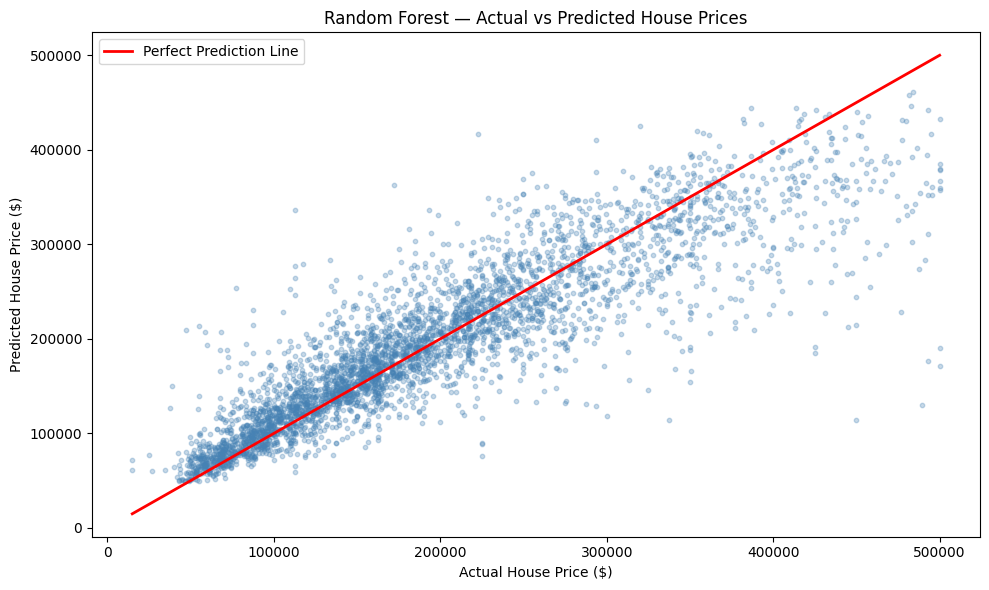

Actual vs Predicted graph saved!


In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_predictions, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction Line')
plt.title('Random Forest — Actual vs Predicted House Prices')
plt.xlabel('Actual House Price ($)')
plt.ylabel('Predicted House Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("Actual vs Predicted graph saved!")

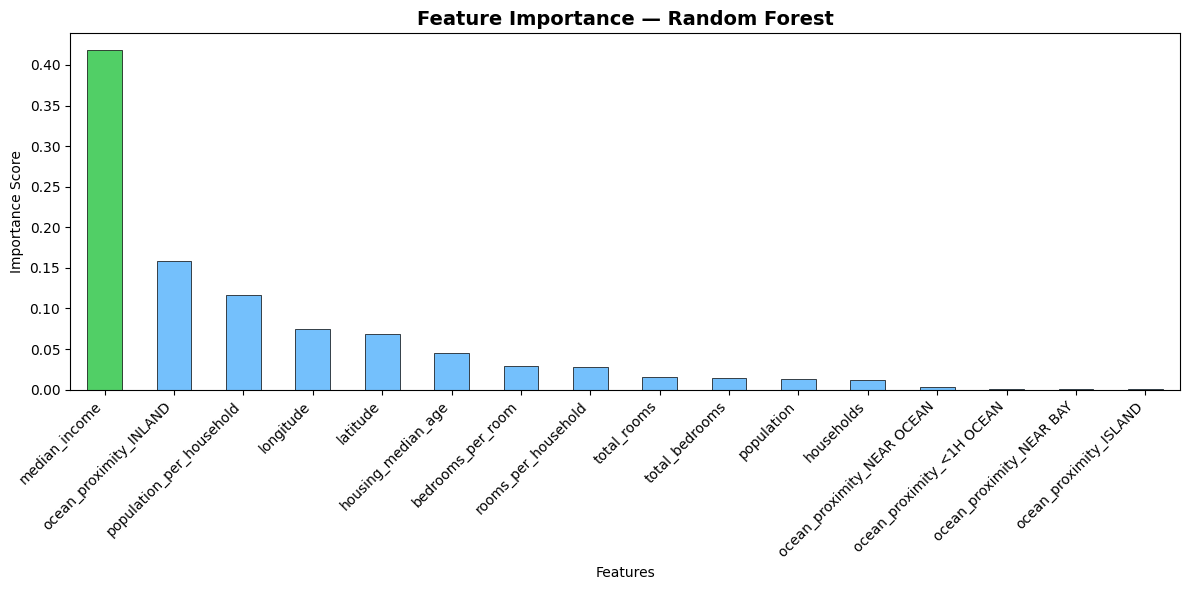

Feature importance graph saved!

Top 5 most important features:
median_income               0.418086
ocean_proximity_INLAND      0.158770
population_per_household    0.116283
longitude                   0.074774
latitude                    0.069181
dtype: float64


In [15]:
# Showing which features matter most to Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, 
                                index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#51cf66' if i == 0 else '#74c0fc' for i in range(len(feature_importance))]
feature_importance.plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance graph saved!")
print("\nTop 5 most important features:")
print(feature_importance.head())

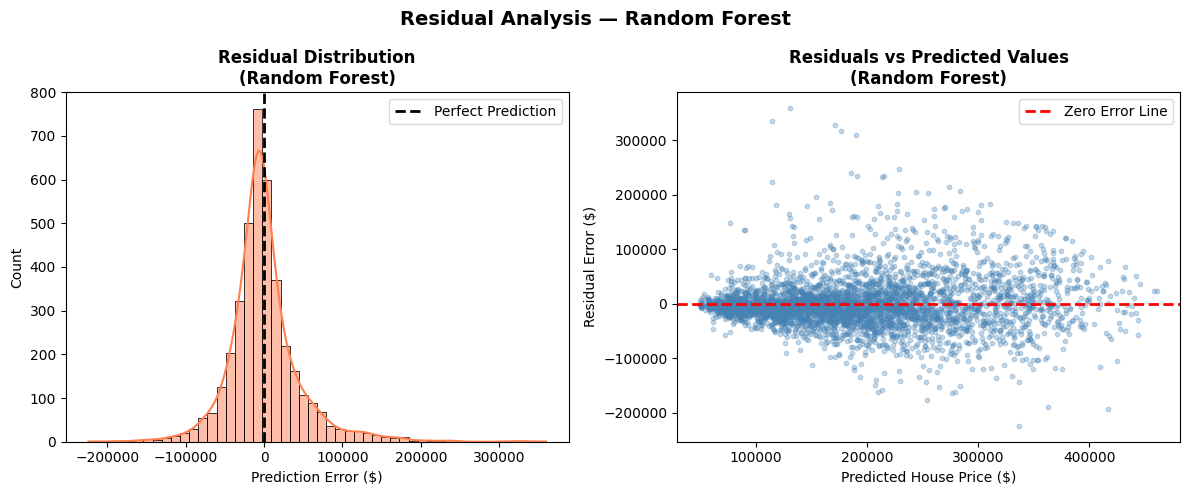

Residual analysis saved!


In [16]:
# Calculating residuals (difference between actual and predicted)
residuals = y_test - rf_predictions

plt.figure(figsize=(12, 5))

# Plot 1 - Residual Distribution
plt.subplot(1, 2, 1)
sns.histplot(residuals, bins=50, kde=True, color='coral')
plt.axvline(x=0, color='black', linewidth=2, linestyle='--', label='Perfect Prediction')
plt.title('Residual Distribution\n(Random Forest)', fontweight='bold')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Count')
plt.legend()

# Plot 2 - Residuals vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(rf_predictions, residuals, alpha=0.3, color='steelblue', s=10)
plt.axhline(y=0, color='red', linewidth=2, linestyle='--', label='Zero Error Line')
plt.title('Residuals vs Predicted Values\n(Random Forest)', fontweight='bold')
plt.xlabel('Predicted House Price ($)')
plt.ylabel('Residual Error ($)')
plt.legend()

plt.suptitle('Residual Analysis — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Residual analysis saved!")

In [17]:
import pickle

# Saving Random Forest model professionally
pickle.dump(rf_model, open('random_forest_model.pkl', 'wb'))

# Saving model parameters for reference
model_params = {
    'model_name': 'Random Forest Regressor',
    'n_estimators': 100,
    'random_state': 42,
    'r2_score': 0.7850,
    'mae': 30802,
    'rmse': 46297
}

import json
with open('model_params.json', 'w') as f:
    json.dump(model_params, f, indent=4)

print("=" * 45)
print("Best Model Saved Successfully!")
print("=" * 45)
print("Model: Random Forest Regressor")
print("R2 Score: 0.7850")
print("MAE: $30,802")
print("RMSE: $46,297")
print("Files saved:")
print("   random_forest_model.pkl  - ML model")
print("   model_params.json        - model details")
print("=" * 45)

Best Model Saved Successfully!
Model: Random Forest Regressor
R2 Score: 0.7850
MAE: $30,802
RMSE: $46,297
Files saved:
   random_forest_model.pkl  - ML model
   model_params.json        - model details


In [19]:
print("=" * 55)
print("   SMART HOUSE PRICE PREDICTION SYSTEM")
print("   Project Summary")
print("=" * 55)

print("\n DATASET")
print(f"   Source      : California Housing Dataset")
print(f"   Total Rows  : 20,640")
print(f"   Features    : 10 original + 3 engineered")

print("\n PREPROCESSING")
print(f"   Missing Values Fixed    : 207")
print(f"   Duplicates Removed      : 0")
print(f"   Outliers Removed        : capped values")
print(f"   New Features Created    : 3")
print(f"   Encoding Done           : ocean_proximity")
print(f"   Scaling Done            : StandardScaler")

print("\n MODELS TRAINED")
print(f"   1. Linear Regression  - R2: 0.6119")
print(f"   2. Decision Tree      - R2: 0.5910")
print(f"   3. Random Forest      - R2: 0.7850  BEST")
print(f"   4. Gradient Boosting  - R2: 0.7495")

print("\n BEST MODEL")
print(f"   Model  : Random Forest Regressor")
print(f"   R2     : 0.7850")
print(f"   MAE    : $30,802")
print(f"   RMSE   : $46,297")

print("\n FILES SAVED")
print(f"   housing_cleaned.csv      - cleaned data")
print(f"   random_forest_model.pkl  - best ML model")
print(f"   scaler.pkl               - feature scaler")
print(f"   model_params.json        - model details")
print(f"   eda_summary.png          - EDA graphs")
print(f"   model_comparison.png     - model comparison")
print(f"   actual_vs_predicted.png  - predictions graph")
print(f"   feature_importance.png   - feature importance")
print(f"   residual_analysis.png    - residual analysis")

print("\n" + "=" * 55)
print("   ML Implementation Complete!")
print("   Next Step: Web Application Development")
print("=" * 55)

   SMART HOUSE PRICE PREDICTION SYSTEM
   Project Summary

 DATASET
   Source      : California Housing Dataset
   Total Rows  : 20,640
   Features    : 10 original + 3 engineered

 PREPROCESSING
   Missing Values Fixed    : 207
   Duplicates Removed      : 0
   Outliers Removed        : capped values
   New Features Created    : 3
   Encoding Done           : ocean_proximity
   Scaling Done            : StandardScaler

 MODELS TRAINED
   1. Linear Regression  - R2: 0.6119
   2. Decision Tree      - R2: 0.5910
   3. Random Forest      - R2: 0.7850  BEST
   4. Gradient Boosting  - R2: 0.7495

 BEST MODEL
   Model  : Random Forest Regressor
   R2     : 0.7850
   MAE    : $30,802
   RMSE   : $46,297

 FILES SAVED
   housing_cleaned.csv      - cleaned data
   random_forest_model.pkl  - best ML model
   scaler.pkl               - feature scaler
   model_params.json        - model details
   eda_summary.png          - EDA graphs
   model_comparison.png     - model comparison
   actual_vs_pre